
# Titanic Dataset Machine Learning 과제 

In [ ]:
# %pip install -U kaggle
# python -m kaggle datasets list
%pip install scikit-learn
# %pip install matplotlib

In [40]:
import psutil

memory = psutil.virtual_memory()

print(f"전체 RAM : {memory.total / 1024**3:.1f} GB")
print(f"사용 RAM : {memory.used / 1024**3:.1f} GB")
print(f"사용률   : {memory.percent}%")
print(f"여유 RAM : {memory.available / 1024**3:.1f} GB")

전체 RAM : 15.9 GB
사용 RAM : 12.4 GB
사용률   : 77.6%
여유 RAM : 3.6 GB


In [10]:
 
import pandas   as pd
import numpy  as np
import matplotlib 
import seaborn  
import sklearn  

import matplotlib.pyplot as plt
  

print(f'sklearn: {sklearn.__version__}')
print(f'numpy: {np.__version__}')
print(f'pandas: {pd.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'seaborn: {seaborn.__version__}')


sklearn: 1.9.0
numpy: 2.5.2
pandas: 3.0.5
matplotlib: 3.11.1
seaborn: 0.13.2


In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import accuracy_score

In [12]:
# ============================================================
# Dataset Total Structure and Info
# ============================================================

def inspect_dataset(data, sample_size=10, descr_size=300):
    """
    다양한 형태의 데이터 구조를 범용적으로 확인한다.

    지원:
    - pandas DataFrame / Series
    - dict / sklearn Bunch
    - numpy ndarray
    - list / tuple
    - scalar
    """

    rows = []

    # ========================================================
    # DataFrame
    # ========================================================

    if isinstance(data, pd.DataFrame):

        for column in data.columns:

            value = data[column]

            rows.append({
                "Branch": column,
                "DType": str(value.dtype),
                "Struc.": f"{data.shape}",
                "Count": len(value),
                "Missing": int(value.isna().sum()),
                "Null": bool(value.isna().any()),
                "Unique cnt": int(value.nunique(dropna=True)),
                "Distribution": value.value_counts(
                    dropna=False
                ).head(sample_size).to_dict(),
                "Sample": value.head(sample_size).tolist()
            })

        return pd.DataFrame(rows)

    # ========================================================
    # Series
    # ========================================================

    if isinstance(data, pd.Series):

        value = data

        rows.append({
            "Branch": value.name or "Series",
            "DType": str(value.dtype),
            "Struc.": f"{value.shape}",
            "Count": len(value),
            "Missing": int(value.isna().sum()),
            "Null": bool(value.isna().any()),
            "Unique cnt": int(value.nunique(dropna=True)),
            "Distribution": value.value_counts(
                dropna=False
            ).head(sample_size).to_dict(),
            "Sample": value.head(sample_size).tolist()
        })

        return pd.DataFrame(rows)

    # ========================================================
    # dict / sklearn Bunch
    # ========================================================

    if isinstance(data, dict):
        items = data.items()

    elif hasattr(data, "keys"):
        items = (
            (key, data[key])
            for key in data.keys()
        )

    else:
        items = [("DATA", data)]

    # ========================================================
    # Object Inspection
    # ========================================================

    for key, value in items:

        data_type = type(value).__name__

        structure = "-"
        count = 0
        missing = 0
        null_status = False
        unique_count = "-"
        distribution = "-"
        sample = "-"

        # ----------------------------------------------------
        # DataFrame
        # ----------------------------------------------------

        if isinstance(value, pd.DataFrame):

            structure = f"{value.shape}"
            count = len(value)
            missing = int(value.isna().sum().sum())
            null_status = missing > 0
            sample = value.head(sample_size)

        # ----------------------------------------------------
        # Series
        # ----------------------------------------------------

        elif isinstance(value, pd.Series):

            structure = f"{value.shape}"
            count = len(value)
            missing = int(value.isna().sum())
            null_status = missing > 0

            unique_count = int(
                value.nunique(dropna=True)
            )

            distribution = value.value_counts(
                dropna=False
            ).head(sample_size).to_dict()

            sample = value.head(sample_size).tolist()

        # ----------------------------------------------------
        # ndarray
        # ----------------------------------------------------

        elif isinstance(value, np.ndarray):

            structure = f"{value.shape}"

            count = (
                value.shape[0]
                if value.ndim > 0
                else 1
            )

            missing = int(pd.isna(value).sum())
            null_status = missing > 0

            sample = (
                repr(value[:sample_size])
                if value.ndim > 0
                else repr(value)
            )

            if value.ndim == 1:

                try:

                    unique, counts = np.unique(
                        value,
                        return_counts=True
                    )

                    unique_count = len(unique)

                    distribution = ", ".join(
                        f"{u}:{c}"
                        for u, c in zip(unique, counts)
                    )

                except TypeError:

                    unique_count = "-"
                    distribution = "-"

            elif value.ndim == 2:

                if np.issubdtype(value.dtype, np.number):

                    distribution = (
                        f"min={value.min():.2f}, "
                        f"max={value.max():.2f}, "
                        f"mean={value.mean():.2f}"
                    )

        # ----------------------------------------------------
        # list / tuple
        # ----------------------------------------------------

        elif isinstance(value, (list, tuple)):

            structure = f"len={len(value)}"
            count = len(value)

            arr = np.array(value, dtype=object)

            missing = int(pd.isna(arr).sum())
            null_status = missing > 0

            sample = repr(value[:sample_size])

            try:

                unique = pd.unique(arr)

                unique_count = len(unique)

                distribution = ", ".join(
                    map(str, unique[:sample_size])
                )

            except Exception:

                unique_count = "-"
                distribution = "-"

        # ----------------------------------------------------
        # 문자열
        # ----------------------------------------------------

        elif isinstance(value, str):

            structure = f"len={len(value)}"
            count = 1

            sample = (
                value[:descr_size] + " ..."
                if key == "DESCR"
                else value
            )

            unique_count = 1

        # ----------------------------------------------------
        # None
        # ----------------------------------------------------

        elif value is None:

            null_status = True
            missing = 1
            sample = np.nan

        # ----------------------------------------------------
        # 기타 scalar / object
        # ----------------------------------------------------

        else:

            count = 1

            try:
                missing = int(pd.isna(value))
            except Exception:
                missing = 0

            null_status = missing > 0
            sample = repr(value)
            unique_count = 1

        # ====================================================
        # 결과 저장
        # ====================================================

        rows.append({
            "Branch": key,
            "DType": data_type,
            "Struc.": structure,
            "Count": count,
            "Missing": missing,
            "Null": null_status,
            "Unique cnt": unique_count,
            "Distribution": distribution,
            "Sample": sample
        })

    return pd.DataFrame(rows)

## 1. 데이터 확인  

In [13]:
 
# 기본설정
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# Constant
FILE_NAME = "titanic/train.csv" 
ENCODING = "utf-8"

df_raw =  pd.read_csv(
    FILE_NAME,
    sep=",",
    encoding=ENCODING,
    header=0,
    index_col=None,
    na_values=["-", "없음", "N/A"]
)

df_raw.shape

(891, 12)

In [14]:
for col in df_raw.columns:
    print(f"{col}: {df_raw[col].nunique()}개") 
    # print(f"{col}") 

# df_raw.head()
df_raw.describe() 

PassengerId: 891개
Survived: 2개
Pclass: 3개
Name: 891개
Sex: 2개
Age: 88개
SibSp: 7개
Parch: 7개
Ticket: 681개
Fare: 248개
Cabin: 147개
Embarked: 3개


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
# 2. 원본 데이터셋 전체 구조
display(inspect_dataset(df_raw)) 

,Branch,DType,Struc.,Count,Missing,Null,Unique cnt,Distribution,Sample
0,PassengerId,int64,"(891, 12)",891,0,False,891,"{1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: ...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
1,Survived,int64,"(891, 12)",891,0,False,2,"{0: 549, 1: 342}","[0, 1, 1, 1, 0, 0, 0, 0, 1, 1]"
2,Pclass,int64,"(891, 12)",891,0,False,3,"{3: 491, 1: 216, 2: 184}","[3, 1, 3, 1, 3, 3, 1, 3, 3, 2]"
3,Name,str,"(891, 12)",891,0,False,891,"{'Braund, Mr. Owen Harris': 1, 'Cumings, Mrs. ...","[Braund, Mr. Owen Harris, Cumings, Mrs. John B..."
4,Sex,str,"(891, 12)",891,0,False,2,"{'male': 577, 'female': 314}","[male, female, female, female, male, male, mal..."
5,Age,float64,"(891, 12)",891,177,True,88,"{nan: 177, 24.0: 30, 22.0: 27, 18.0: 26, 28.0:...","[22.0, 38.0, 26.0, 35.0, 35.0, nan, 54.0, 2.0,..."
6,SibSp,int64,"(891, 12)",891,0,False,7,"{0: 608, 1: 209, 2: 28, 4: 18, 3: 16, 8: 7, 5: 5}","[1, 1, 0, 1, 0, 0, 0, 3, 0, 1]"
7,Parch,int64,"(891, 12)",891,0,False,7,"{0: 678, 1: 118, 2: 80, 5: 5, 3: 5, 4: 4, 6: 1}","[0, 0, 0, 0, 0, 0, 0, 1, 2, 0]"
8,Ticket,str,"(891, 12)",891,0,False,681,"{'347082': 7, '1601': 7, 'CA. 2343': 7, '31012...","[A/5 21171, PC 17599, STON/O2. 3101282, 113803..."
9,Fare,float64,"(891, 12)",891,0,False,248,"{8.05: 43, 13.0: 42, 7.8958: 38, 7.75: 34, 26....","[7.25, 71.2833, 7.925, 53.1, 8.05, 8.4583, 51...."


### Feature Analysis

| Feature | DType | Missing | Missing % | Unique | Type | 분석 / COMMENT | 전처리추천 |
|---|---|---:|---:|---:|---|---|---|
| PassengerId | int64 | 0 | 0.0% | 891 | ID | x - Primary Key. | - |
| Pclass | int64 | 0 | 0.0% | 3 | Ordinal |  | X |
| Name | str | 0 | 0.0% | 891 | Categorical/Text | Title 분리 | |
| Sex | str | 0 | 0.0% | 2 | Categorical | male, female | One-hot encoding |
| Age | float64 | 177 | 19.9% | 88 | Numerical | 결측치 처리 | MinMaxScaler |
| SibSp | int64 | 0 | 0.0% | 7 | Numerical | 동반인 여부 | MinMaxScaler |
| Parch | int64 | 0 | 0.0% | 7 | Numerical | 동반인 여부 | MinMaxScaler |
| Ticket | str | 0 | 0.0% | 681 | Categorical/Text | 티켓 연속성 | X |
| Fare | float64 | 0 | 0.0% | 248 | Numerical | 요금체계확인 | RobustScaler |
| Cabin | str | 687 | 77.1% | 147 | Categorical/Text | 데이터존재여부체크 | |
| Embarked | str | 2 | 0.2% | 3 | Categorical | 항구별 특성 | |


1. PassengerId(키정보), Embarked(탑승항구), Cabin(결측치)은 분석 feature에서 제외해서 진행
2. Age는  19.9% 결측치는 아래 상세기준 기술
3. 스케일러는 모델별 성능테스트를 위해서 1개로 통일할것 (위 내용은 참조만)
4. Fare, SlbSp, Parch 정보 쏠림있음 (75%, max ). Fare 0  있음, pclass 50% 
- Age 결측치는 177건으로 스케일링 오류를 줄이기 위해 중앙값으로 반영  (중앙값 기준 : Pclass + Title 그룹의 중앙값. 단 Master의 경우 표본이 적어 Title만 적용) <br> 

 

In [16]:
# Age 결측자료 확인 (특이점없음)
df_raw.loc[
    df_raw["Age"].isna()
].sort_values(["Pclass","Ticket"]).head() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
475,476,0,1,"Clifford, Mr. George Quincy",male,NaN,0,0,110465,52.00,A14,S
507,508,1,1,"Bradley, Mr. George (""George Arthur Brayton"")",male,NaN,0,0,111427,26.55,NaN,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.00,NaN,S
815,816,0,1,"Fry, Mr. Richard",male,NaN,0,0,112058,0.00,B102,S
766,767,0,1,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.60,NaN,C


## 2.  Feature Engineering  

In [17]:
# ============================================================
# 원본 보존
# ============================================================

df_modified = df_raw.copy()

In [18]:
# ============================================================
# Title 추출
# Name에서 호칭(Title) 추출
# ============================================================

def extract_title(name):

    title = name.split(",")[1].split(".")[0].strip()

    # 명확한 여성 호칭
    if title in ["Miss", "Mrs", "Mlle", "Mme", "Ms", "Lady", "the Countess", "Dona"]:
        return title

    # 명확한 남성 호칭
    elif title in ["Mr", "Master", "Rev", "Major", "Col",
                   "Don", "Sir", "Capt", "Jonkheer", "Rev"]:
        return title

    # 성별이 명확하지 않거나 기타
    else:
        return "Other"
        

df_modified["Title"] = (
    df_modified["Name"]
    .apply(extract_title)
)

# ============================================================
# 동행인 여부
# SibSp / Parch 또는 동일 Ticket 승객이 있으면 1
# ============================================================

# ticket_count = (
#     df_modified["Ticket"]
#     .value_counts()
# )

df_modified["HasCompanion"] = (
    (df_modified["SibSp"] > 0) |
    (df_modified["Parch"] > 0) 
    # |
    # (df_modified["Ticket"].map(ticket_count) > 1)
).astype(int)

# ============================================================
# 동행인 그룹
# SibSp / Parch / 동일 Ticket 승객 수를 기준으로 그룹화
# ============================================================

# ticket_count = (
#     df_modified["Ticket"]
#     .value_counts()
# )

def make_companion_group(df):
    companion_count = (
        df["SibSp"]
        + df["Parch"] 
    )

    return pd.cut(
        companion_count,
        bins=[-1, 0, 2, float("inf")],
        labels=["Alone", "SmallGroup", "LargeGroup"]
    )
 

df_modified["CompanionGroup"] = make_companion_group(df_modified)

# ============================================================
# FamilySize 생성
# SibSp + Parch + 1
# ============================================================

df_modified["FamilySize"] = (
    df_modified["SibSp"]
    + df_modified["Parch"]
    + 1
)

# ============================================================
# 아동 여부
# Age가 16세 미만이면 1
# ============================================================

df_modified["IsChild"] = (
    df_modified["Age"] < 16
).astype(int)


# ============================================================
# Age group (컬럼만 새엉 : 결측치 채운뒤 내용 채우기 )
#  
# ============================================================
df_modified["AgeGroup"] = None


# ============================================================
# FareLevel Feature
# Fare 분포의 25%, 50%, 75% 기준으로 구간화
# ============================================================

df_modified["FareLevel"] = pd.cut(
    df_modified["Fare"],
    bins=[0, 7.9104, 14.4542, 31.0, float("inf")],
    labels=[
        "Low",
        "Middle-Low",
        "Middle-High",
        "High"
    ],
    include_lowest=False
)

# Categorical → Object
# Free 값을 추가하기 위해 변환
df_modified["FareLevel"] = (
    df_modified["FareLevel"]
    .astype("object")
)

df_modified.loc[
    df_modified["Fare"] == 0,
    "FareLevel"
] = "Free"


# ============================================================
# Cabin 정보 유무
# Cabin 정보가 있으면 1, 없으면 0
# ============================================================

df_modified["HasCabin"] = (
    df_modified["Cabin"].notna()
).astype(int)


# # ============================================================
# # 무료 승선 여부
# # Fare가 0이면 1
# # ============================================================

# df_modified["IsFreeFare"] = (
#     df_modified["Fare"] == 0
# ).astype(int)


In [19]:
df_modified.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,HasCompanion,CompanionGroup,FamilySize,IsChild,AgeGroup,FareLevel,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,SmallGroup,2,0,None,Low,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,SmallGroup,2,0,None,High,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0,Alone,1,0,None,Middle-Low,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1,SmallGroup,2,0,None,High,1


## 3. 전처리

In [ ]:
## feature 별로 분류해서 처리 


#1.제외 Feature

FEATURES_EXCEPT = [
    "PassengerId",
    "Cabin", 
]


#2.DataType별 Feature  
FEATURES_CATEGORICAL = [
    "Sex",    
    "Title",
    "AgeGroup",
    # "HasCabin", 
    "FareLevel",
    "Embarked",
    "CompanionGroup"
] 

FEATURES_NUMERIC = [
    "Age",    
    "SibSp",
    "Parch",
    "Fare",    
    "FamilySize",
]

FEATURES_ORDINAL = [
    "Pclass"
]

#3.Target 분리 (0 1 코드화 되어있음)
FEATURES_TARGET =  "Survived"  

# 4. Feature Engineering 후보
FEATURE_ENGINEERING_FEATURES = [
    "Name",  
]


# 5. 현재 적용할 Feature Engineering
FEATURES_BINARY  = [
    "HasCompanion",
    "IsChild",
    # "IsFreeFare"
]

### 4. 데이터 분할 (Train / Validation )

In [20]:
#Age 결측치 중앙값 산출 (Train 산출 정보를 Validation, test Dataset에도 적용) 

# ============================================================
# 2. Train 데이터에서 Age 중앙값 산출
# ============================================================

def get_age_medians(df):

    data = df.copy()

    data["Title"] = data["Name"].apply(extract_title)

    # --------------------------------------------------------
    # ① Master 전체 중앙값
    #    → Pclass 구분하지 않음
    # --------------------------------------------------------

    master_median = (
        data.loc[
            data["Title"] == "Master",
            "Age"
        ]
        .dropna()
        .median()
    )


    # --------------------------------------------------------
    # ② Title + Pclass 중앙값
    #    → Master 제외
    # --------------------------------------------------------

    title_pclass_medians = (
        data.loc[
            data["Title"] != "Master"
        ]
        .dropna(subset=["Age"])
        .groupby(
            ["Title", "Pclass"]
        )["Age"]
        .median()
        .to_dict()
    )


    # --------------------------------------------------------
    # ③ Pclass 중앙값
    # --------------------------------------------------------

    pclass_medians = (
        data
        .dropna(subset=["Age"])
        .groupby("Pclass")["Age"]
        .median()
        .to_dict()
    )


    # --------------------------------------------------------
    # ④ 전체 Age 중앙값
    # --------------------------------------------------------

    global_median = data["Age"].median()


    # Train에서 계산한 값들을 하나로 저장
    age_medians = {
        "master": master_median,
        "title_pclass": title_pclass_medians,
        "pclass": pclass_medians,
        "global": global_median
    }

    return age_medians

In [21]:
def apply_age_medians(df, age_medians):

    data = df.copy()

    # Title 생성
    data["Title"] = data["Name"].apply(extract_title)

    # Age 결측 행만 처리
    missing_index = data.index[
        data["Age"].isna()
    ]

    for index in missing_index:

        title = data.loc[index, "Title"]
        pclass = data.loc[index, "Pclass"]

        # ① Master
        if title == "Master":

            if not pd.isna(age_medians["master"]):

                data.loc[index, "Age"] = (
                    age_medians["master"]
                )

                continue

        # ② Title + Pclass
        key = (title, pclass)

        if key in age_medians["title_pclass"]:

            data.loc[index, "Age"] = (
                age_medians["title_pclass"][key]
            )

            continue

        # ③ Pclass
        if pclass in age_medians["pclass"]:

            data.loc[index, "Age"] = (
                age_medians["pclass"][pclass]
            )

            continue

        # ④ 전체 중앙값
        data.loc[index, "Age"] = (
            age_medians["global"]
        )

    # Title은 모델 Feature로 사용하므로 삭제하지 않음

    return data

In [24]:
from sklearn.model_selection import train_test_split

#1.Feature / Target 분리
x = df_modified[
    FEATURES_CATEGORICAL
    + FEATURES_NUMERIC
    + FEATURES_ORDINAL 
    + FEATURES_BINARY    
    + FEATURE_ENGINEERING_FEATURES   
]

y = df_modified[
    FEATURES_TARGET
]

#2.Train / Validation 분리 ( 8:2 ) : Target 비유은 유지하는 방향으로
x_train, x_valid, y_train, y_valid = train_test_split (
    x, y,
    test_size = 0.2,
    random_state = 42,
    stratify=y   
)

#백업
x_train_backup = x_train.copy()
x_val_backup   = x_valid.copy()
# x_test_backup  = x_test.copy()

In [25]:
y.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [27]:
# ============================================================
# Age 결측치 처리
# ============================================================

# Train 데이터로만 Age 중앙값 산출
age_medians = get_age_medians(x_train)

# Age 결측치 처리
x_train = apply_age_medians(x_train, age_medians)
x_valid = apply_age_medians(x_valid, age_medians) 


# ============================================================
# AgeGroup Feature 생성
# ============================================================

def create_age_group(age):

    if age <= 6:
        return "0_6"

    elif age <= 12:
        return "7_12"

    elif age <= 25:
        return "13_25"

    elif age <= 45:
        return "26_45"

    elif age <= 65:
        return "46_65"

    else:
        return "66_plus"


x_train["AgeGroup"] = (
    x_train["Age"]
    .apply(create_age_group)
)

x_valid["AgeGroup"] = (
    x_valid["Age"]
    .apply(create_age_group)
)
 
# ============================================================
# Experiment Step
# ============================================================

STEP = 2


STEP_FEATURES = {

    1: (
        FEATURES_CATEGORICAL
        + FEATURES_NUMERIC
        + FEATURES_ORDINAL
    ),

    2: (
        FEATURES_CATEGORICAL
        + FEATURES_NUMERIC
        + FEATURES_ORDINAL
        + FEATURES_BINARY
    ),

    3: (
        FEATURES_CATEGORICAL
        + [f for f in FEATURES_NUMERIC if f != "Age"]
        + FEATURES_ORDINAL
        + FEATURES_BINARY
    )
}


MODEL_FEATURES = STEP_FEATURES[STEP]


# ============================================================
# Model Feature 선택
# ============================================================ 

x_train_model = x_train[MODEL_FEATURES].copy()
x_valid_model = x_valid[MODEL_FEATURES].copy() 

## 5. Pipeline  
-  AI 참조
- LogisticRegression
KNeighborsClassifier
DecisionTreeClassifier
GradientBoostingClassifier
AdaBoostClassifier

In [28]:
# ============================================================
# Preprocessor
# ============================================================

# LogisticRegression / KNN
# Numeric → StandardScaler, MinMaxScaler
# Categorical → OneHotEncoder
# Ordinal / Binary → 그대로 사용

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            # MinMaxScaler(),
            [f for f in FEATURES_NUMERIC if f in MODEL_FEATURES]
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            [f for f in FEATURES_CATEGORICAL if f in MODEL_FEATURES]
        ),
        (
            "ordinal",
            "passthrough",
            [f for f in FEATURES_ORDINAL if f in MODEL_FEATURES]
        ),
        (
            "binary",
            "passthrough",
            [f for f in FEATURES_BINARY if f in MODEL_FEATURES]
        )
    ],
    remainder="drop"
)


# Tree 계열
# Numeric → Scaling 하지 않음
# Categorical → OneHotEncoder
# Ordinal / Binary → 그대로 사용

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            [f for f in FEATURES_NUMERIC if f in MODEL_FEATURES]
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            [f for f in FEATURES_CATEGORICAL if f in MODEL_FEATURES]
        ),
        (
            "ordinal",
            "passthrough",
            [f for f in FEATURES_ORDINAL if f in MODEL_FEATURES]
        ),
        (
            "binary",
            "passthrough",
            [f for f in FEATURES_BINARY if f in MODEL_FEATURES]
        )
    ],
    remainder="drop"
)

In [29]:
# ============================================================
# Model Pipeline
# ============================================================ 

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {

    # Scaling 적용
    "LogisticRegression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier())
    ]),

    # Scaling 미적용
    "DecisionTree": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]),

    "RandomForest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]),
    
    "GradientBoosting": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ]),

    "AdaBoost": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", AdaBoostClassifier(random_state=42))
    ]),

    # "SVC": Pipeline([
    #     ("preprocessor", preprocessor),
    #     ("model", SVC()
    #     )
    # ]),

    # "XGBoost": Pipeline([
    #     ("preprocessor", preprocessor),
    #     ("model", XGBClassifier(
    #         n_estimators=100,
    #         max_depth=3,
    #         learning_rate=0.1,
    #         random_state=42,
    #         eval_metric="logloss"
    #     ))
    # ])
}

In [30]:
df_modified.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,HasCompanion,CompanionGroup,FamilySize,IsChild,AgeGroup,FareLevel,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1,SmallGroup,2,0,None,Low,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,SmallGroup,2,0,None,High,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0,Alone,1,0,None,Middle-Low,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1,SmallGroup,2,0,None,High,1


In [ ]:
x_train_model.head(5)

,Sex,Title,AgeGroup,FareLevel,Embarked,CompanionGroup,Age,SibSp,Parch,Fare,FamilySize,Pclass,HasCompanion,IsChild
692,male,Mr,26_45,High,S,Alone,27.0,0,0,56.4958,1,3,0,0
481,male,Mr,26_45,Free,S,Alone,30.0,0,0,0.0000,1,2,0,0
527,male,Mr,26_45,High,S,Alone,40.0,0,0,221.7792,1,1,0,0
855,female,Mrs,13_25,Middle-Low,S,SmallGroup,18.0,0,1,9.3500,2,3,1,0
801,female,Mrs,26_45,Middle-High,S,SmallGroup,31.0,1,1,26.2500,3,2,1,0


## 6. 모델학습 

In [32]:
# ============================================================
# Model Training & Validation
# ============================================================

results = {}

for name, model in models.items():

    # Train
    model.fit(
        x_train_model,
        y_train
    )

    # Validation
    y_pred = model.predict(
        x_valid_model
    )

    # Accuracy
    accuracy = accuracy_score(
        y_valid,
        y_pred
    )

    results[name] = accuracy

    print(
        f"{name:20s} : {accuracy:.4f}"
    )

LogisticRegression   : 0.8268
KNN                  : 0.8045
DecisionTree         : 0.7598
RandomForest         : 0.8045
GradientBoosting     : 0.8101
AdaBoost             : 0.8156


In [33]:
# ============================================================
# GridSearchCV
# ============================================================
from sklearn.model_selection import GridSearchCV

param_grids = {

    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1, 10, 100]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15]
    },

    "DecisionTree": {
        "model__max_depth": [2, 3, 4, 5, 6, None],
        "model__min_samples_split": [2, 5, 10]
    },

    "RandomForest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features": ["sqrt", "log2"]
    },

    "GradientBoosting": {
        "model__n_estimators": [50, 100, 150, 200, 300 ],
        "model__learning_rate": [0.03, 0.05, 0.1]
    },

    "AdaBoost": {
        "model__n_estimators": [50, 100, 150],
        "model__learning_rate": [0.5, 1.0, 1.5]
    },

    # # 추가
    # "SVC": {
    #     "model__C": [0.1, 1, 10],
    #     "model__kernel": ["linear", "rbf"] 
    # }, 

    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1]
    }
    
}


# ============================================================
# GridSearch 실행
# ============================================================

grid_results = {}

for name, model in models.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(
        x_train_model,
        y_train
    )

    grid_results[name] = grid

    print(f"\n{name}")
    print("Best Parameter :", grid.best_params_)
    print("Best CV Score  :", f"{grid.best_score_:.4f}")


# ============================================================
# Validation 성능 확인
# ============================================================

print("\n===== Validation Accuracy =====")

grid_validation_results = {}

for name, grid in grid_results.items():

    y_pred = grid.predict(
        x_valid_model
    )

    accuracy = accuracy_score(
        y_valid,
        y_pred
    )

    grid_validation_results[name] = accuracy

    print(
        f"{name:20s} : {accuracy:.4f}"
    )


LogisticRegression
Best Parameter : {'model__C': 0.1}
Best CV Score  : 0.8161

KNN
Best Parameter : {'model__n_neighbors': 15}
Best CV Score  : 0.8091

DecisionTree
Best Parameter : {'model__max_depth': 3, 'model__min_samples_split': 2}
Best CV Score  : 0.8105

RandomForest
Best Parameter : {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best CV Score  : 0.8287

GradientBoosting
Best Parameter : {'model__learning_rate': 0.05, 'model__n_estimators': 300}
Best CV Score  : 0.8245

AdaBoost
Best Parameter : {'model__learning_rate': 1.0, 'model__n_estimators': 150}
Best CV Score  : 0.8231

===== Validation Accuracy =====
LogisticRegression   : 0.8212
KNN                  : 0.8156
DecisionTree         : 0.8212
RandomForest         : 0.8101
GradientBoosting     : 0.8212
AdaBoost             : 0.8212


In [34]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

svc_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC())
])

svc_scores = cross_val_score(
    svc_model,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("SVC 5-Fold Scores:", svc_scores)
print("SVC Mean Accuracy:", svc_scores.mean())

SVC 5-Fold Scores: [0.8041958  0.83916084 0.83802817 0.83098592 0.83802817]
SVC Mean Accuracy: 0.8300797793755539


#### 결과 History 저장

In [36]:
# ============================================================
# Experiment History 저장
# ============================================================

if "experiment_history" not in globals():
    experiment_history = []

    
CURRENT_STEP = 51
CURRENT_FEATURE = "+ ALL FareLevel Title(rev)" 

PREPROCESSING_INFO = {

    "LogisticRegression": {
        "Scaling": "StandardScaler",
        "Encoding": "OneHotEncoder",
        "Imputation": "Age median"
    },

    "KNN": {
        "Scaling": "StandardScaler",
        "Encoding": "OneHotEncoder",
        "Imputation": "Age median"
    },

    "DecisionTree": {
        "Scaling": "None",
        "Encoding": "OneHotEncoder",
        "Imputation": "Age median"
    },
    "RandomForest": {
        "Scaling": "None",
        "Encoding": "OneHotEncoder",
        "Imputation": "Age median"
    },

    "GradientBoosting": {
        "Scaling": "None",
        "Encoding": "OneHotEncoder",
        "Imputation": "Age median"
    },

    "AdaBoost": {
        "Scaling": "None",
        "Encoding": "OneHotEncoder",
        "Imputation": "Age median"
    }
}


for name, grid in grid_results.items():

    preprocessing = PREPROCESSING_INFO[name]

    experiment_history.append({

        "Step": CURRENT_STEP,
        "Feature": CURRENT_FEATURE,
        "Model": name,

        "Scaling": preprocessing["Scaling"],
        "Encoding": preprocessing["Encoding"],
        "Imputation": preprocessing["Imputation"],

        "Best_Parameters": grid.best_params_,
        "CV_Score": grid.best_score_,
        "Validation_Accuracy": grid_validation_results[name]
    })


experiment_history_df = pd.DataFrame(
    experiment_history
)

# experiment_history_df.to_csv(
#     "titanic_model_results.csv",
#     index=False,
#     encoding="utf-8-sig"
# )

 
experiment_history_df

,Step,Feature,Model,Scaling,Encoding,Imputation,Best_Parameters,CV_Score,Validation_Accuracy
0,51,+ ALL FareLevel Title(rev),LogisticRegression,StandardScaler,OneHotEncoder,Age median,{'model__C': 0.1},0.816084,0.821229
1,51,+ ALL FareLevel Title(rev),KNN,StandardScaler,OneHotEncoder,Age median,{'model__n_neighbors': 15},0.809071,0.815642
2,51,+ ALL FareLevel Title(rev),DecisionTree,None,OneHotEncoder,Age median,"{'model__max_depth': 3, 'model__min_samples_sp...",0.810499,0.821229
3,51,+ ALL FareLevel Title(rev),RandomForest,None,OneHotEncoder,Age median,"{'model__max_depth': 10, 'model__max_features'...",0.828691,0.810056
4,51,+ ALL FareLevel Title(rev),GradientBoosting,None,OneHotEncoder,Age median,"{'model__learning_rate': 0.05, 'model__n_estim...",0.824525,0.821229
5,51,+ ALL FareLevel Title(rev),AdaBoost,None,OneHotEncoder,Age median,"{'model__learning_rate': 1.0, 'model__n_estima...",0.823126,0.821229


In [37]:
# ============================================================
# Soft Voting Ensemble
# ============================================================

from sklearn.ensemble import VotingClassifier

# 현재 GridSearch에서 최적 모델 가져오기
best_lr = grid_results["LogisticRegression"].best_estimator_
best_dt = grid_results["DecisionTree"].best_estimator_
best_gb = grid_results["GradientBoosting"].best_estimator_


# Soft Voting
voting_model = VotingClassifier(
    estimators=[
        ("lr", best_lr),
        ("dt", best_dt),
        ("gb", best_gb)
    ],
    voting="soft"
)


# 학습
voting_model.fit(
    x_train_model,
    y_train
)


# Validation 예측
y_pred = voting_model.predict(
    x_valid_model
)

# Validation 확률
y_prob = voting_model.predict_proba(
    x_valid_model
)[:, 1]

In [38]:
# ============================================================
# 앙상블 평가
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)



print("\n===== Voting Ensemble Evaluation =====")
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

accuracy = accuracy_score(y_valid, y_pred)

precision = precision_score(
    y_valid,
    y_pred
)

recall = recall_score(
    y_valid,
    y_pred
)

f1 = f1_score(
    y_valid,
    y_pred
)

roc_auc = roc_auc_score(
    y_valid,
    y_prob
)

cm = confusion_matrix(
    y_valid,
    y_pred
)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("Confusion Matrix:")
print(cm)


===== Voting Ensemble Evaluation =====
Accuracy  : 0.8380
Precision : 0.8125
Recall    : 0.7536
F1 Score  : 0.7820
ROC-AUC   : 0.8625
Confusion Matrix:
[[98 12]
 [17 52]]


#### << 기타 정보 >>

In [39]:
# ============================================================
# FINAL MODEL COMPARISON
# Single Models + Voting Ensemble
# ============================================================

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# 1. 최적 모델 가져오기
# ============================================================

final_models = {
    "LogisticRegression":
        grid_results["LogisticRegression"].best_estimator_,

    "DecisionTree":
        grid_results["DecisionTree"].best_estimator_,

    "RandomForest":
        grid_results["RandomForest"].best_estimator_,

    "GradientBoosting":
        grid_results["GradientBoosting"].best_estimator_,

    "AdaBoost":
        grid_results["AdaBoost"].best_estimator_,
}


# ============================================================
# 2. 결과 저장
# ============================================================

final_results = []


# ============================================================
# 3. 단일 모델 평가
# ============================================================

for name, model in final_models.items():

    # 학습
    model.fit(
        x_train_model,
        y_train
    )

    # 예측
    y_pred = model.predict(
        x_valid_model
    )

    # 확률 예측
    y_proba = model.predict_proba(
        x_valid_model
    )[:, 1]

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        y_pred
    ).ravel()

    # 결과
    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1": f1_score(y_valid, y_pred),
        "ROC-AUC": roc_auc_score(y_valid, y_proba),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


# ============================================================
# 4. Voting Ensemble 평가
# ============================================================

voting_model.fit(
    x_train_model,
    y_train
)

# 확률
voting_proba = voting_model.predict_proba(
    x_valid_model
)[:, 1]


# ------------------------------------------------------------
# Threshold = 0.5
# ------------------------------------------------------------

voting_pred_05 = (
    voting_proba >= 0.5
).astype(int)


tn, fp, fn, tp = confusion_matrix(
    y_valid,
    voting_pred_05
).ravel()


final_results.append({
    "Model": "Voting Ensemble (0.5)",
    "Accuracy": accuracy_score(y_valid, voting_pred_05),
    "Precision": precision_score(y_valid, voting_pred_05),
    "Recall": recall_score(y_valid, voting_pred_05),
    "F1": f1_score(y_valid, voting_pred_05),
    "ROC-AUC": roc_auc_score(y_valid, voting_proba),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
})


# ------------------------------------------------------------
# Threshold = 0.6
# ------------------------------------------------------------

voting_pred_06 = (
    voting_proba >= 0.6
).astype(int)


tn, fp, fn, tp = confusion_matrix(
    y_valid,
    voting_pred_06
).ravel()


final_results.append({
    "Model": "Voting Ensemble (0.6)",
    "Accuracy": accuracy_score(y_valid, voting_pred_06),
    "Precision": precision_score(y_valid, voting_pred_06),
    "Recall": recall_score(y_valid, voting_pred_06),
    "F1": f1_score(y_valid, voting_pred_06),
    "ROC-AUC": roc_auc_score(y_valid, voting_proba),
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
})


# ============================================================
# 5. DataFrame 생성
# ============================================================

final_results_df = pd.DataFrame(
    final_results
)


# ============================================================
# 6. Accuracy 기준 정렬
# ============================================================

final_results_df = final_results_df.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 7. 출력
# ============================================================

print("=" * 100)
print("                    FINAL MODEL COMPARISON")
print("=" * 100)

display(
    final_results_df.round(4)
)

                    FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP
0,Voting Ensemble (0.6),0.8380,0.8704,0.6812,0.7642,0.8625,103,7,22,47
1,Voting Ensemble (0.5),0.8380,0.8125,0.7536,0.7820,0.8625,98,12,17,52
2,LogisticRegression,0.8212,0.7937,0.7246,0.7576,0.8719,97,13,19,50
3,AdaBoost,0.8212,0.7606,0.7826,0.7714,0.8493,93,17,15,54
4,DecisionTree,0.8212,0.7681,0.7681,0.7681,0.8586,94,16,16,53
5,GradientBoosting,0.8212,0.8136,0.6957,0.7500,0.8327,99,11,21,48
6,RandomForest,0.8101,0.7692,0.7246,0.7463,0.8380,95,15,19,50


## 결론

최종적으로 Titanic 생존 예측에 사용한 주요 Feature 정리

### 최종 Feature

| Feature        | 설명                                                      | 적용 목적                  |
| -------------- | ------------------------------------------------------- | ---------------------- |
| Title          | Name에서 추출한 호칭                                           | 성별·연령·사회적 지위 등의 정보 반영  |
| AgeGroup       | Age를 연령 구간으로 변환                                         | 연령대별 생존 패턴 반영          |
| FamilySize     | SibSp + Parch + 1                                       | 동승 가족 규모 반영            |
| Fare           | 승객 운임                                                   | 좌석 등급 및 경제적 수준의 간접적 반영 |
| FareLevel      | Fare를 Low / Middle-Low / Middle-High / High / Free로 구간화 | 운임 수준에 따른 생존 차이 반영     |
| Pclass         | 객실 등급                                                   | 객실 등급 및 사회·경제적 차이 반영   |
| Sex            | 성별                                                      | 생존 여부와 관련된 주요 Feature  |
| SibSp          | 함께 탑승한 형제·배우자 수                                         | 가족·동행 관계 반영            |
| Parch          | 함께 탑승한 부모·자녀 수                                          | 가족·동행 관계 반영            |
| Embarked       | 탑승 항구                                                   | 승객 집단별 차이 반영           |
| HasCompanion   | 동행인 존재 여부                                               | 혼자 탑승 여부 반영            |
| IsChild        | 어린이 여부                                                  | 연령에 따른 생존 특성 반영        |
| CompanionGroup | Alone / SmallGroup / LargeGroup                         | 동행 규모에 따른 생존 특성 반영     |

### Feature Engineering

* `Name` → Title 추출
* `Age` → AgeGroup 구간화
* `SibSp + Parch + 1` → FamilySize 생성
* `Fare` → FareLevel 구간화
* `Fare = 0` → Free 별도 그룹 처리
* 가족 및 동행 규모 → CompanionGroup, HasCompanion 생성
* 연령 기준 → IsChild 생성
* Age 결측치 → Train 데이터 기준 중앙값 적용

### 모델 비교

비교 대상 분류 모델

* Logistic Regression
* KNN
* Decision Tree
* Random Forest
* Gradient Boosting
* AdaBoost
* Voting Ensemble

모델별 Hyperparameter 탐색 및 모델 특성에 따른 전처리 적용

* Scaling
* One-Hot Encoding
* 모델별 Preprocessor 구성

### Ensemble

최종 Ensemble 모델

```text
Voting Ensemble
├── Logistic Regression
├── Decision Tree
└── Gradient Boosting
```

Soft Voting을 통한 각 모델의 예측 확률 결합 및 종합적인 예측 결과 산출

### Validation 결과

| Metric    | Voting Ensemble |
| --------- | --------------: |
| Accuracy  |          0.8380 |
| Precision |          0.8125 |
| Recall    |          0.7536 |
| F1 Score  |          0.7820 |
| ROC-AUC   |          0.8625 |

### 최종 제출 모델

* Model: Voting Ensemble
* Feature: ALL Feature
* Voting: Soft Voting
* Threshold: 0.5
* **Kaggle Score: 0.77751**

기존 단일 모델 최고 Kaggle Score 0.77272 대비 **0.00479 향상**

### 최종 결론

Title, Sex, AgeGroup, FamilySize, Fare, FareLevel, Pclass를 중심으로 가족·동행 및 탑승 관련 Feature 추가

여러 모델의 예측 확률을 Soft Voting으로 결합한 Voting Ensemble을 최종 제출 모델로 선정

Feature 추가에 따른 모델별 성능 차이 및 Feature Importance 차이 확인

Validation 성능과 실제 Test 성능 간 차이를 통한 모델 일반화 성능의 중요성 확인


특이사항) Feature 최적화로 5개까지 줄인 단일 모델보다 Voting Ensemble에서 모든 feature를 적용한 데이터가 더 안정적으로 나옴 

--- 

- Feature Importance ( 모델별 영향도 0 이상인 것만 )

In [803]:
# ============================================================
# Model Feature Importance
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. 결과 저장
# ============================================================

all_importance = {}


# ============================================================
# 2. GridSearch 최적 모델별 Feature Importance 추출
# ============================================================

for model_name, grid in grid_results.items():

    # 최적 모델
    best_model = grid.best_estimator_

    # 전처리 후 Feature 이름
    feature_names = (
        best_model
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    # 실제 모델
    model = best_model.named_steps["model"]


    # --------------------------------------------------------
    # Tree 계열
    # --------------------------------------------------------

    if hasattr(model, "feature_importances_"):

        importance = model.feature_importances_


    # --------------------------------------------------------
    # Logistic Regression / Linear SVM
    # --------------------------------------------------------

    elif hasattr(model, "coef_"):

        importance = np.abs(model.coef_[0])


    # --------------------------------------------------------
    # Feature Importance를 제공하지 않는 모델
    # --------------------------------------------------------

    else:

        print(f"{model_name}: Feature Importance 지원 안 함")
        continue


    # --------------------------------------------------------
    # DataFrame 생성
    # --------------------------------------------------------

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })


    # 중요도 높은 순서
    importance_df = (
        importance_df
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )


    # 저장
    all_importance[model_name] = importance_df


# ============================================================
# 3. 모델별 결과 출력
#    Importance > 0 인 Feature만 출력
# ============================================================

for model_name, importance_df in all_importance.items():

    print("\n" + "=" * 70)
    print(f"{model_name} Feature Importance")
    print("=" * 70)

    importance_positive = importance_df[
        importance_df["Importance"] > 0
    ].reset_index(drop=True)

    display(
        importance_positive
    )

KNN: Feature Importance 지원 안 함

LogisticRegression Feature Importance


,Feature,Importance
0,categorical__Title_Mr,0.872057
1,ordinal__Pclass,0.756424
2,categorical__Sex_male,0.681713
3,categorical__Sex_female,0.680975
4,categorical__Title_Mrs,0.487813
5,categorical__AgeGroup_0_6,0.406182
6,numeric__Age,0.381513
7,categorical__Title_Master,0.348726
8,numeric__SibSp,0.272728
9,categorical__FareLevel_Free,0.258274



DecisionTree Feature Importance


,Feature,Importance
0,categorical__Title_Mr,0.629344
1,ordinal__Pclass,0.155370
2,numeric__FamilySize,0.082402
3,numeric__Fare,0.077409
4,categorical__Title_Rev,0.049442
5,categorical__FareLevel_Middle-Low,0.006032



RandomForest Feature Importance


,Feature,Importance
0,numeric__Fare,0.125136
1,categorical__Sex_female,0.121234
2,categorical__Title_Mr,0.116034
3,categorical__Sex_male,0.102451
4,numeric__Age,0.087387
5,ordinal__Pclass,0.077064
6,numeric__FamilySize,0.039914
7,categorical__Title_Miss,0.032845
8,categorical__Title_Mrs,0.030183
9,numeric__SibSp,0.028231



GradientBoosting Feature Importance


,Feature,Importance
0,categorical__Title_Mr,0.316885
1,numeric__Fare,0.175693
2,ordinal__Pclass,0.126832
3,numeric__Age,0.094593
4,categorical__Sex_female,0.072092
5,categorical__Sex_male,0.058825
6,numeric__FamilySize,0.052153
7,categorical__Title_Rev,0.020142
8,categorical__Embarked_S,0.017265
9,categorical__AgeGroup_0_6,0.011305



AdaBoost Feature Importance


,Feature,Importance
0,numeric__Fare,0.357930
1,numeric__FamilySize,0.154062
2,categorical__Title_Mr,0.111460
3,numeric__Age,0.110594
4,categorical__Title_Rev,0.094373
5,ordinal__Pclass,0.088258
6,categorical__Sex_male,0.025542
7,categorical__AgeGroup_7_12,0.024689
8,numeric__SibSp,0.023905
9,categorical__AgeGroup_46_65,0.007127


 ## - EDA

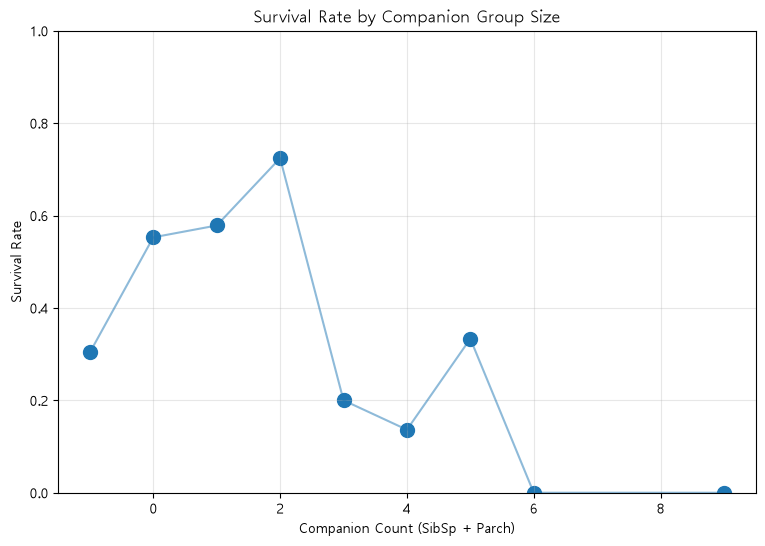

In [ ]:
df_modified["CompanionCount"] = (
    df_modified["SibSp"] + df_modified["Parch"] -1
)

import matplotlib.pyplot as plt

survival_rate = (
    df_modified
    .groupby("CompanionCount")["Survived"]
    .mean()
)

plt.figure(figsize=(9, 6))

plt.scatter(
    survival_rate.index,
    survival_rate.values,
    s=100
)

plt.plot(
    survival_rate.index,
    survival_rate.values,
    alpha=0.5
)

plt.xlabel("Companion Count (SibSp + Parch)")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Companion Group Size")

plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.show()

In [ ]:
sibsp_survival = (
    df_modified.groupby("SibSp")["Survived"]
      .mean()
      .reset_index()
)

sibsp_survival["Survived"] *= 100

sibsp_survival

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    sibsp_survival["SibSp"],
    sibsp_survival["Survived"]
)

plt.xlabel("SibSp")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by SibSp")

plt.show()

In [ ]:
parch_survival = (
    df_modified.groupby("Parch")["Survived"]
      .mean()
      .reset_index()
)

parch_survival["Survived"] *= 100

parch_survival

plt.figure(figsize=(8, 5))

plt.bar(
    parch_survival["Parch"],
    parch_survival["Survived"]
)

plt.xlabel("Parch")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Parch")

plt.show()

In [ ]:
df_modified["FamilySize"] = df_modified["SibSp"] + df_modified["Parch"] + 1

df_modified["FamilySize"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10, 5),
    title="Family Size Distribution"
)

plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.show()



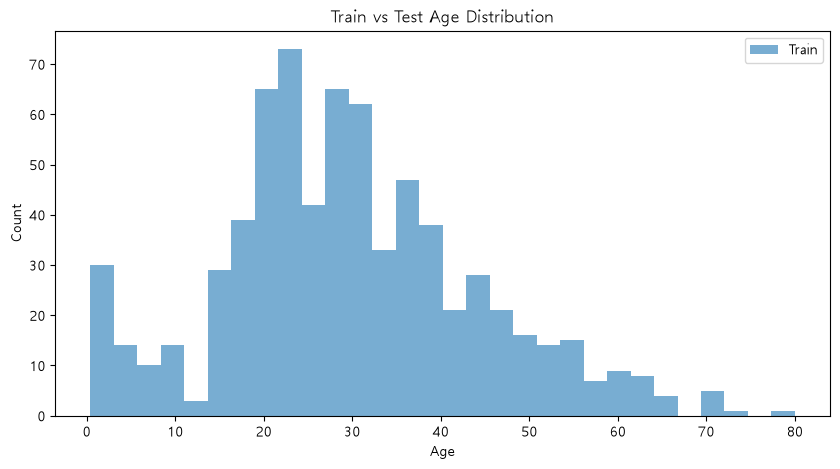

In [603]:
# ============================================================
# Age EDA - Train / Test 비교
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df_modified["Age"].dropna(),
    bins=30,
    alpha=0.6,
    label="Train"
)

# plt.hist(
#     test_df["Age"].dropna(),
#     bins=30,
#     alpha=0.6,
#     label="Test"
# )

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Train vs Test Age Distribution")
plt.legend()
plt.show()

       Sex FareGroup  count  survived  survival_rate     ratio
0   female       0~8     48        33       0.687500  0.053872
1   female      8~15     66        41       0.621212  0.074074
2   female     15~30     87        62       0.712644  0.097643
3   female     30~60     41        30       0.731707  0.046016
4   female    60~100     38        35       0.921053  0.042649
5   female   100~200     22        20       0.909091  0.024691
6   female      200+     12        12       1.000000  0.013468
7     male       0~8    193        19       0.098446  0.216611
8     male      8~15    151        21       0.139073  0.169473
9     male     15~30    112        30       0.267857  0.125701
10    male     30~60     71        24       0.338028  0.079686
11    male    60~100     31         8       0.258065  0.034792
12    male   100~200     11         5       0.454545  0.012346
13    male      200+      8         2       0.250000  0.008979
       Sex FareGroup  count     ratio  survival_rate
0 

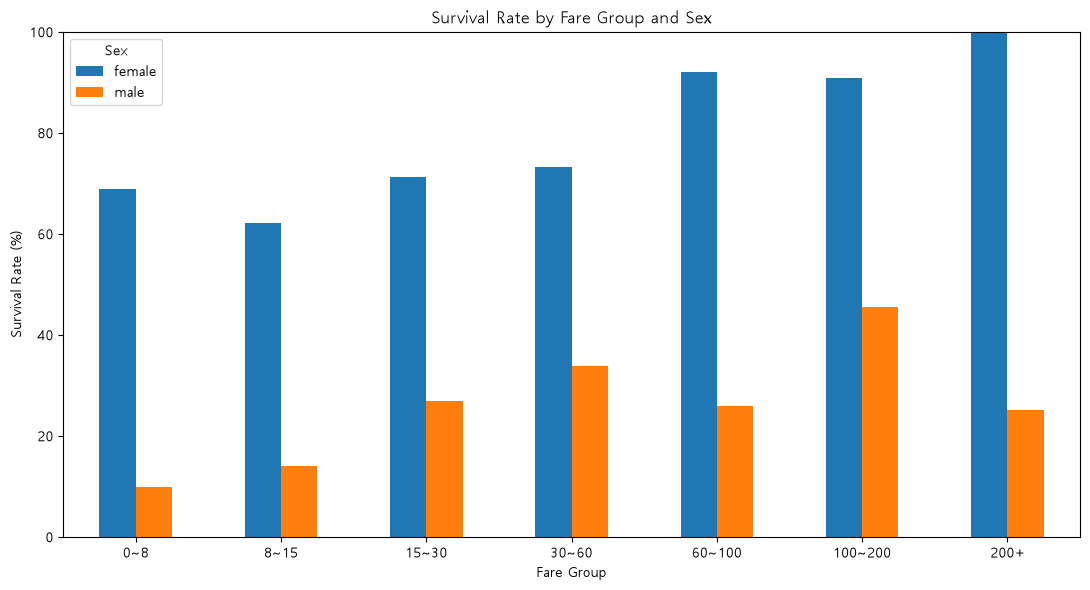

In [677]:
# ============================================================
# Fare 구간 × Sex별 생존률 + 인원 비율
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Fare 구간
fare_bins = [0, 8, 15, 30, 60, 100, 200, float("inf")]
fare_labels = [
    "0~8",
    "8~15",
    "15~30",
    "30~60",
    "60~100",
    "100~200",
    "200+"
]

df_fare = df_modified.copy()

df_fare["FareGroup"] = pd.cut(
    df_fare["Fare"],
    bins=fare_bins,
    labels=fare_labels,
    include_lowest=True
)

# ------------------------------------------------------------
# 성별 × Fare구간별 집계
# ------------------------------------------------------------

fare_sex_result = (
    df_fare
    .groupby(["Sex", "FareGroup"], observed=False)["Survived"]
    .agg(
        count="count",
        survived="sum",
        survival_rate="mean"
    )
    .reset_index()
)

# 전체 데이터 대비 인원 비율
total_count = len(df_fare)

fare_sex_result["ratio"] = (
    fare_sex_result["count"] / total_count
)

print(fare_sex_result)

# 보기 좋게
print(
    fare_sex_result[
        ["Sex", "FareGroup", "count", "ratio", "survival_rate"]
    ]
)

# ============================================================
# 그래프
# ============================================================

plot_data = fare_sex_result.copy()

plot_data["survival_rate"] *= 100

pivot_survival = plot_data.pivot(
    index="FareGroup",
    columns="Sex",
    values="survival_rate"
)

ax = pivot_survival.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title("Survival Rate by Fare Group and Sex")
ax.set_xlabel("Fare Group")
ax.set_ylabel("Survival Rate (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

       Sex  Pclass FareGroup  count  ratio  survival_rate
0   female       1       0~8      0  0.000            NaN
1   female       1      8~15      0  0.000            NaN
2   female       1     15~30      7  0.008         85.714
3   female       1     30~60     20  0.022        100.000
4   female       1    60~100     33  0.037        100.000
5   female       1   100~200     22  0.025         90.909
6   female       1      200+     12  0.013        100.000
7   female       2       0~8      0  0.000            NaN
8   female       2      8~15     30  0.034         90.000
9   female       2     15~30     36  0.040         91.667
10  female       2     30~60      8  0.009        100.000
11  female       2    60~100      2  0.002        100.000
12  female       2   100~200      0  0.000            NaN
13  female       2      200+      0  0.000            NaN
14  female       3       0~8     48  0.054         68.750
15  female       3      8~15     36  0.040         38.889
16  female    

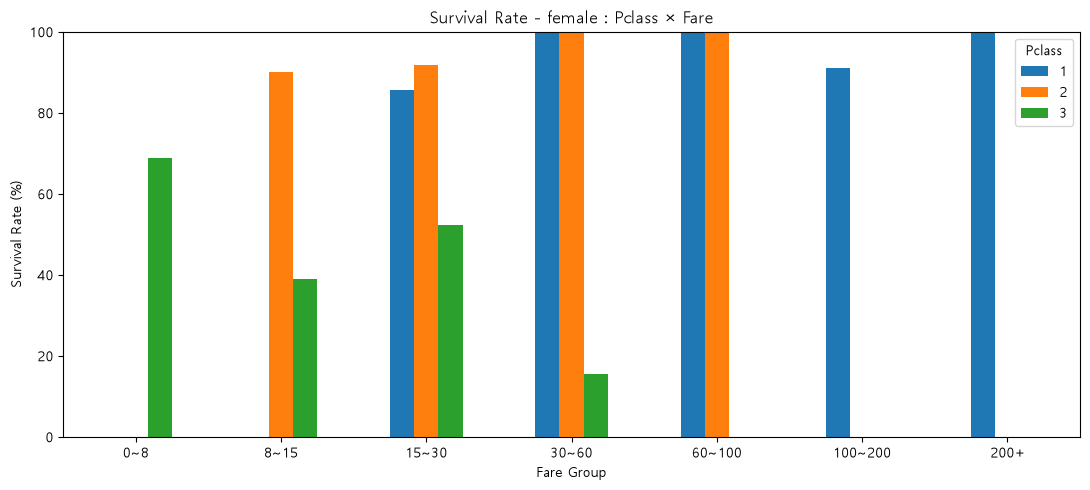

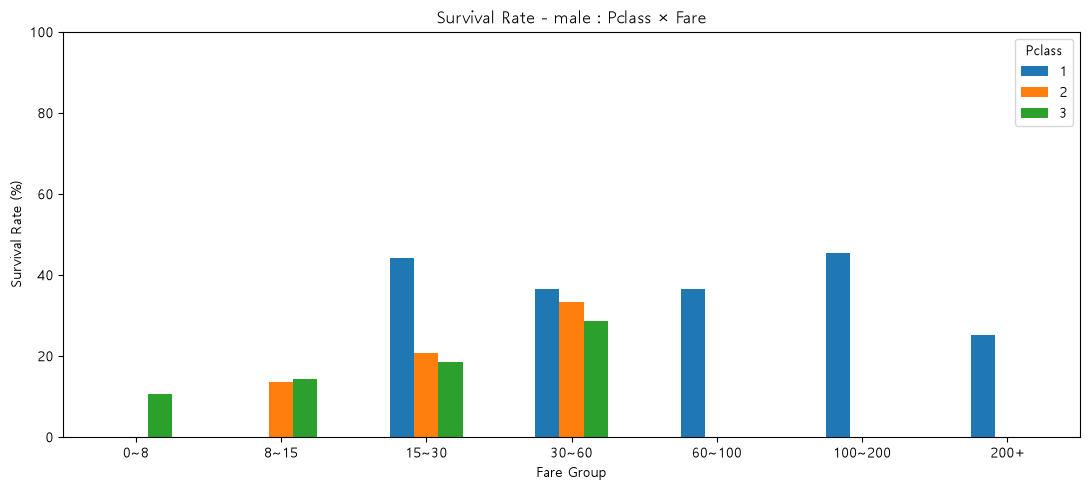

In [678]:
# ============================================================
# Sex + Pclass + FareGroup별 생존률
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

df_fare = df_modified.copy()

# Fare 구간
fare_bins = [0, 8, 15, 30, 60, 100, 200, float("inf")]

fare_labels = [
    "0~8",
    "8~15",
    "15~30",
    "30~60",
    "60~100",
    "100~200",
    "200+"
]

df_fare["FareGroup"] = pd.cut(
    df_fare["Fare"],
    bins=fare_bins,
    labels=fare_labels,
    include_lowest=True
)

# ============================================================
# 집계
# ============================================================

result = (
    df_fare
    .groupby(
        ["Sex", "Pclass", "FareGroup"],
        observed=False
    )["Survived"]
    .agg(
        count="count",
        survived="sum",
        survival_rate="mean"
    )
    .reset_index()
)

result["ratio"] = result["count"] / len(df_fare)

# 생존률 %
result["survival_rate"] = result["survival_rate"] * 100

print(
    result[
        [
            "Sex",
            "Pclass",
            "FareGroup",
            "count",
            "ratio",
            "survival_rate"
        ]
    ].round(3)
)

# ============================================================
# 그래프
# ============================================================

for sex in ["female", "male"]:

    temp = result[result["Sex"] == sex]

    pivot = temp.pivot(
        index="FareGroup",
        columns="Pclass",
        values="survival_rate"
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(11, 5)
    )

    ax.set_title(
        f"Survival Rate - {sex} : Pclass × Fare"
    )

    ax.set_xlabel("Fare Group")
    ax.set_ylabel("Survival Rate (%)")
    ax.set_ylim(0, 100)

    plt.xticks(rotation=0)
    plt.legend(title="Pclass")
    plt.tight_layout()
    plt.show()

In [680]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_eda = df_modified.copy()

# Pclass별 Fare 중앙값
fare_median = (
    df_eda
    .groupby("Pclass")["Fare"]
    .transform("median")
)

# Pclass 내부에서 Fare 상/하위 그룹
df_eda["FareLevel"] = np.where(
    df_eda["Fare"] < fare_median,
    "Low",
    "High"
)

# 생존률
fare_survival = (
    df_eda
    .groupby(["Pclass", "FareLevel"])["Survived"]
    .agg(
        Count="count",
        SurvivalRate="mean"
    )
    .reset_index()
)

fare_survival["SurvivalRate"] *= 100

fare_survival

,Pclass,FareLevel,Count,SurvivalRate
0,1,High,108,74.074074
1,1,Low,108,51.851852
2,2,High,92,58.695652
3,2,Low,92,35.869565
4,3,High,261,25.287356
5,3,Low,230,23.043478


In [681]:
# ============================================================
# Pclass × FareLevel × Sex 생존률 EDA
# ============================================================

fare_sex_survival = (
    df_eda
    .groupby(
        ["Pclass", "FareLevel", "Sex"],
        observed=True
    )["Survived"]
    .agg(
        Count="count",
        SurvivalRate="mean"
    )
    .reset_index()
)

fare_sex_survival["SurvivalRate"] *= 100

fare_sex_survival

,Pclass,FareLevel,Sex,Count,SurvivalRate
0,1,High,female,67,97.014925
1,1,High,male,41,36.585366
2,1,Low,female,27,96.296296
3,1,Low,male,81,37.037037
4,2,High,female,47,93.617021
5,2,High,male,45,22.222222
6,2,Low,female,29,89.655172
7,2,Low,male,63,11.111111
8,3,High,female,95,40.000000
9,3,High,male,166,16.867470


In [682]:
# ============================================================
# Pclass 3 × Female × FareLevel
# Age / FamilySize EDA
# ============================================================

target = df_eda[
    (df_eda["Pclass"] == 3) &
    (df_eda["Sex"] == "female")
].copy()

# 그룹별 기본 통계
target.groupby("FareLevel").agg(
    Count=("Survived", "count"),
    SurvivalRate=("Survived", "mean"),
    AgeMean=("Age", "mean"),
    AgeMedian=("Age", "median"),
    FamilySizeMean=("FamilySize", "mean"),
    FamilySizeMedian=("FamilySize", "median")
)

,Count,SurvivalRate,AgeMean,AgeMedian,FamilySizeMean,FamilySizeMedian
FareLevel,,,,,,
High,95,0.400000,21.657534,21.0,3.463158,3.0
Low,49,0.693878,21.982759,22.0,1.204082,1.0


In [683]:
family_eda = (
    target
    .groupby("FamilySize")["Survived"]
    .agg(
        Count="count",
        SurvivalRate="mean"
    )
    .reset_index()
)

family_eda["SurvivalRate"] *= 100

family_eda

,FamilySize,Count,SurvivalRate
0,1,60,61.666667
1,2,29,51.724138
2,3,22,54.545455
3,4,6,83.333333
4,5,9,0.000000
5,6,5,0.000000
6,7,8,37.500000
7,8,2,0.000000
8,11,3,0.000000
